# Measuring Stock Seasonality

## Proposed pipeline:

1. <b>Augmented Dickey-Fuller test on raw closing prices</b>:

   Check if series if non-stationary (probably will be). If not, skip to step 3.

2. <b>ADF on Intraday_Action_Pct</b>:

   If stationary, proceed.

3. <b>Season-Trend decomposition using LOESS</b>:

   Confirm seasonality actually exists and identify periods (weekly, monthly, quarterly, yearly).

4. <b>SARIMA/SARIMAX</b>:

   If there is correlation between tickers, run SARIMAX with a competing ticker Intraday_Action_Pct as an exogenous variable. Otherwise, use SARIMA.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings("ignore")

TICKERS = ["SONY", "EA", "NTES", "NFLX", "DIS", "CMSA", "SPOT", "LYV", "WMG"]
df = pd.read_parquet("../stock_data.parquet")
ticker_data = {ticker: df[df["Ticker"] == ticker].copy() for ticker in TICKERS}

## Augmented Dickey-Fuller tests


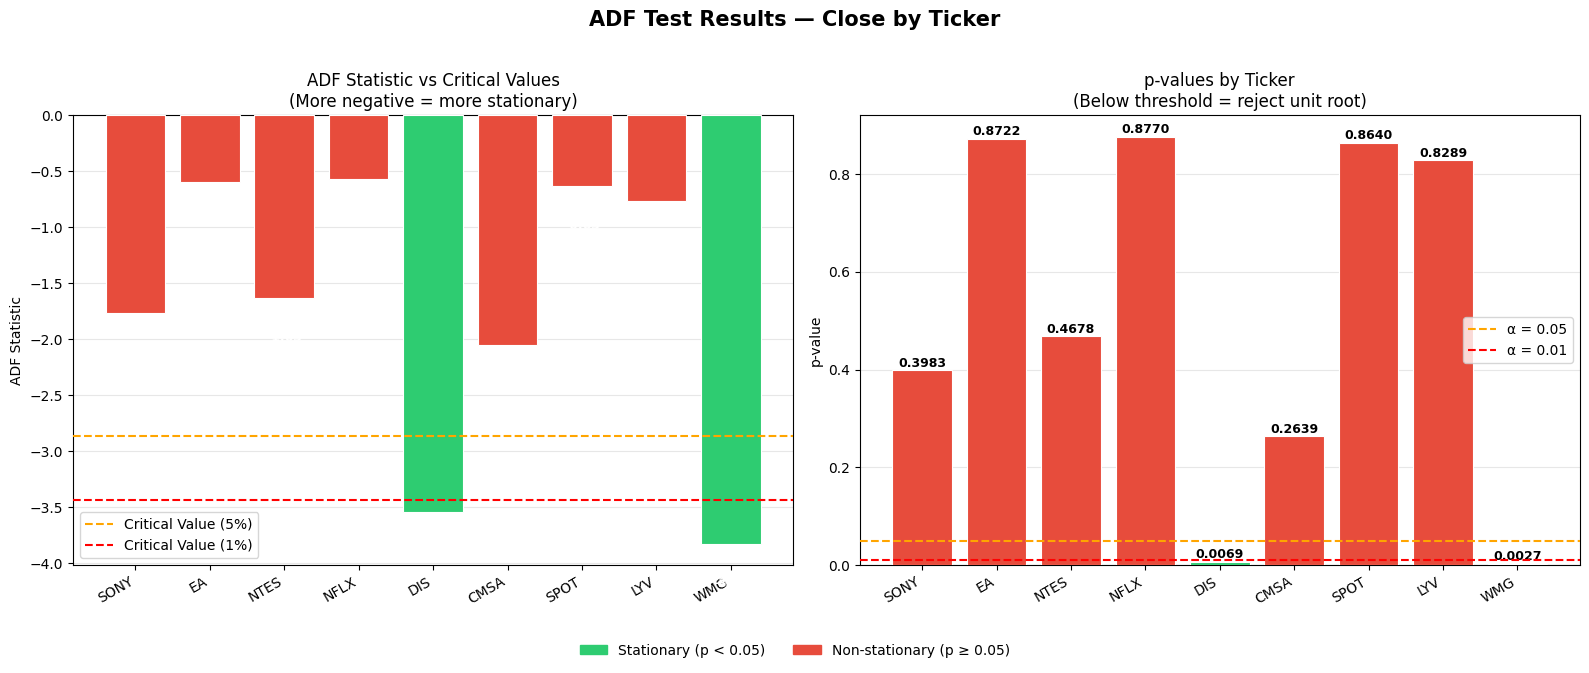

        ADF Statistic  p-value  Critical Value (1%)  Critical Value (5%)  Stationary (5%)
Ticker                                                                                   
SONY          -1.7644   0.3983              -3.4364              -2.8642            False
EA            -0.5946   0.8722              -3.4364              -2.8642            False
NTES          -1.6294   0.4678              -3.4364              -2.8642            False
NFLX          -0.5729   0.8770              -3.4364              -2.8642            False
DIS           -3.5458   0.0069              -3.4364              -2.8642             True
CMSA          -2.0529   0.2639              -3.4364              -2.8642            False
SPOT          -0.6302   0.8640              -3.4364              -2.8642            False
LYV           -0.7661   0.8289              -3.4364              -2.8642            False
WMG           -3.8255   0.0027              -3.4364              -2.8642             True


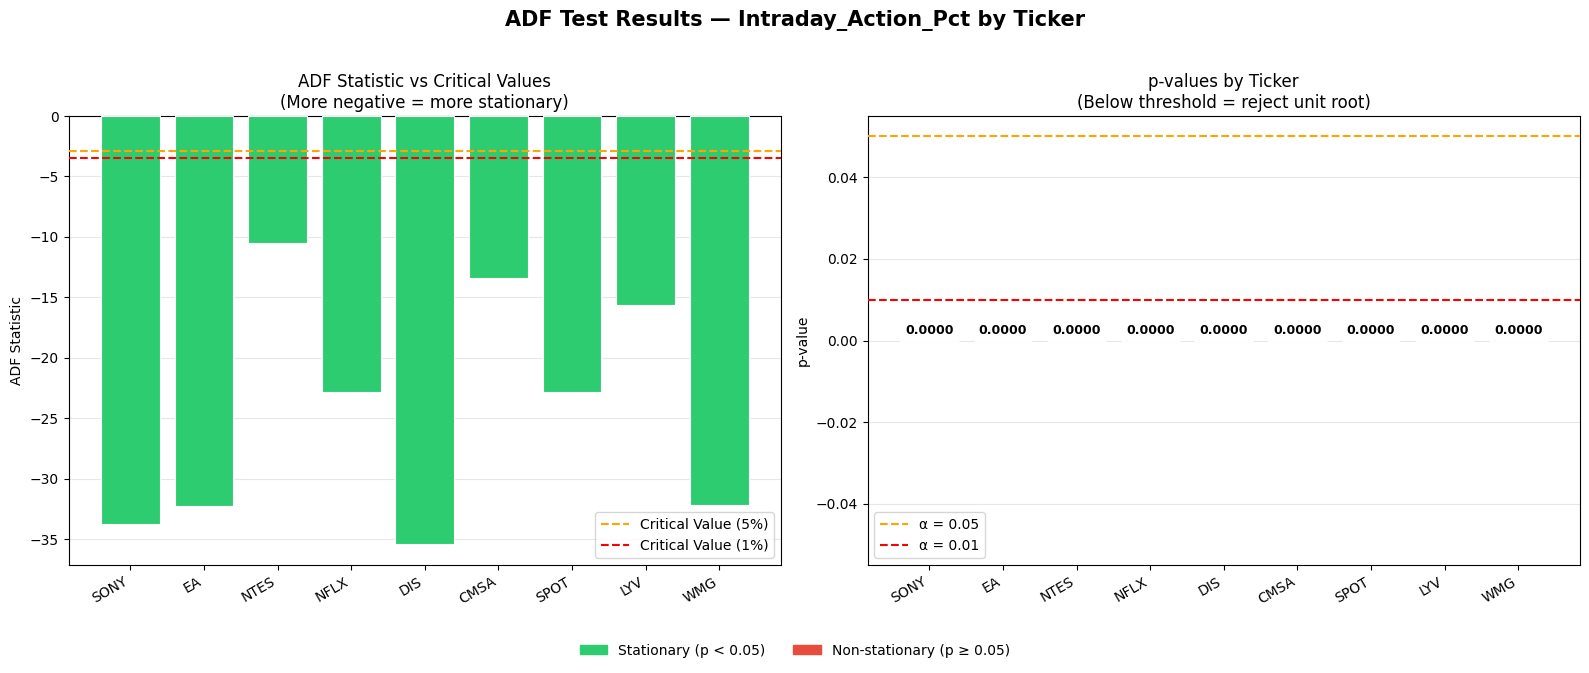

        ADF Statistic  p-value  Critical Value (1%)  Critical Value (5%)  Stationary (5%)
Ticker                                                                                   
SONY         -33.7945      0.0              -3.4364              -2.8642             True
EA           -32.2288      0.0              -3.4364              -2.8642             True
NTES         -10.5147      0.0              -3.4364              -2.8642             True
NFLX         -22.8175      0.0              -3.4364              -2.8642             True
DIS          -35.3798      0.0              -3.4364              -2.8642             True
CMSA         -13.3709      0.0              -3.4364              -2.8642             True
SPOT         -22.8639      0.0              -3.4364              -2.8642             True
LYV          -15.6497      0.0              -3.4364              -2.8642             True
WMG          -32.2239      0.0              -3.4364              -2.8642             True


In [40]:
from statsmodels.tsa.stattools import adfuller


def adf_test(ticker_data, series_name):
    results = []
    for name, df in ticker_data.items():
        series = df[series_name].dropna()
        adf_stat, p_value, _, _, critical_values, _ = adfuller(series)
        results.append(
            {
                "Ticker": name,
                "ADF Statistic": round(adf_stat, 4),
                "p-value": round(p_value, 4),
                "Critical Value (1%)": round(critical_values["1%"], 4),
                "Critical Value (5%)": round(critical_values["5%"], 4),
                "Stationary (5%)": p_value < 0.05,
            }
        )

    return pd.DataFrame(results).set_index("Ticker")


def visualize_adf_results(results_df, series_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        f"ADF Test Results — {series_name} by Ticker",
        fontsize=15,
        fontweight="bold",
        y=1.02,
    )

    colors = ["#2ecc71" if s else "#e74c3c" for s in results_df["Stationary (5%)"]]

    # ADF Statistic vs Critical Values
    ax1 = axes[0]
    x = np.arange(len(results_df))
    bars = ax1.bar(
        x,
        results_df["ADF Statistic"],
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    ax1.axhline(
        results_df["Critical Value (5%)"].iloc[0],
        color="orange",
        linestyle="--",
        linewidth=1.5,
        label="Critical Value (5%)",
        zorder=4,
    )
    ax1.axhline(
        results_df["Critical Value (1%)"].iloc[0],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Critical Value (1%)",
        zorder=4,
    )

    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df.index, rotation=30, ha="right")
    ax1.set_ylabel("ADF Statistic")
    ax1.set_title("ADF Statistic vs Critical Values\n(More negative = more stationary)")
    ax1.legend()
    ax1.grid(axis="y", alpha=0.3, zorder=0)
    ax1.set_axisbelow(True)

    for bar, val in zip(bars, results_df["ADF Statistic"]):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 0.3,
            f"{val:.2f}",
            ha="center",
            va="top",
            fontsize=9,
            color="white",
            fontweight="bold",
        )

    # p-values
    ax2 = axes[1]
    bars2 = ax2.bar(
        x,
        results_df["p-value"],
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        zorder=3,
    )

    ax2.axhline(
        0.05, color="orange", linestyle="--", linewidth=1.5, label="α = 0.05", zorder=4
    )
    ax2.axhline(
        0.01, color="red", linestyle="--", linewidth=1.5, label="α = 0.01", zorder=4
    )

    ax2.set_xticks(x)
    ax2.set_xticklabels(results_df.index, rotation=30, ha="right")
    ax2.set_ylabel("p-value")
    ax2.set_title("p-values by Ticker\n(Below threshold = reject unit root)")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3, zorder=0)
    ax2.set_axisbelow(True)

    for bar, val in zip(bars2, results_df["p-value"]):
        ypos = bar.get_height() + 0.001
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            ypos,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

    # stationary status
    green_patch = mpatches.Patch(color="#2ecc71", label="Stationary (p < 0.05)")
    red_patch = mpatches.Patch(color="#e74c3c", label="Non-stationary (p ≥ 0.05)")
    fig.legend(
        handles=[green_patch, red_patch],
        loc="lower center",
        ncol=2,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
    )

    plt.tight_layout()
    plt.savefig("adf_results.png", dpi=150, bbox_inches="tight")
    plt.show()

    # summary
    print(results_df.to_string())


close_adf_results = adf_test(ticker_data, "Close")
intraday_adf_results = adf_test(ticker_data, "Intraday_Action_Pct")

visualize_adf_results(close_adf_results, "Close")
visualize_adf_results(intraday_adf_results, "Intraday_Action_Pct")

## Granger causality

Does one ticker help forecast another?


In [41]:
from statsmodels.tsa.stattools import grangercausalitytests

SUBINDUSTRIES = {"Gaming": TICKERS[:3], "Streaming": TICKERS[3:6], "Music": TICKERS[6:]}


# Tag each pair with its relationship type
def get_pair_type(t1, t2, subindustries):
    for group, members in subindustries.items():
        if t1 in members and t2 in members:
            return f"Within — {group}"
    return "Cross-group"


results = []
for i in range(len(TICKERS) - 1):
    for j in range(i + 1, len(TICKERS)):
        t1, t2 = TICKERS[i], TICKERS[j]
        data = pd.concat(
            [
                ticker_data[t1]["Intraday_Action_Pct"]
                .reset_index(drop=True)
                .rename(t1),
                ticker_data[t2]["Intraday_Action_Pct"]
                .reset_index(drop=True)
                .rename(t2),
            ],
            axis=1,
        ).dropna()

        test = grangercausalitytests(data, maxlag=5, verbose=False)

        # Pull best p-value across lags
        best_p = min(test[lag][0]["ssr_ftest"][1] for lag in range(1, 6))

        results.append(
            {
                "Pair": f"{t1} → {t2}",
                "Type": get_pair_type(t1, t2, SUBINDUSTRIES),
                "Best p-value": round(best_p, 4),
                "Significant": best_p < 0.05,
            }
        )

results_df = pd.DataFrame(results)
print(results_df.groupby("Type")["Significant"].mean())  # Hit rate by group type
print(
    f"\n{results_df.sort_values('Best p-value').to_string(index=False)}"
)  # All pairs sorted by p-value

Type
Cross-group           0.111111
Within — Gaming       0.333333
Within — Music        0.000000
Within — Streaming    0.000000
Name: Significant, dtype: float64

       Pair               Type  Best p-value  Significant
 SONY → DIS        Cross-group        0.0194         True
 DIS → SPOT        Cross-group        0.0280         True
   EA → WMG        Cross-group        0.0336         True
  SONY → EA    Within — Gaming        0.0438         True
SONY → CMSA        Cross-group        0.0511        False
NTES → CMSA        Cross-group        0.0598        False
 NFLX → WMG        Cross-group        0.0621        False
SONY → NTES    Within — Gaming        0.0664        False
   EA → LYV        Cross-group        0.0945        False
  DIS → WMG        Cross-group        0.1154        False
 NTES → LYV        Cross-group        0.1471        False
 DIS → CMSA Within — Streaming        0.1627        False
  DIS → LYV        Cross-group        0.1691        False
 SPOT → WMG     Within —

## STL decomposition


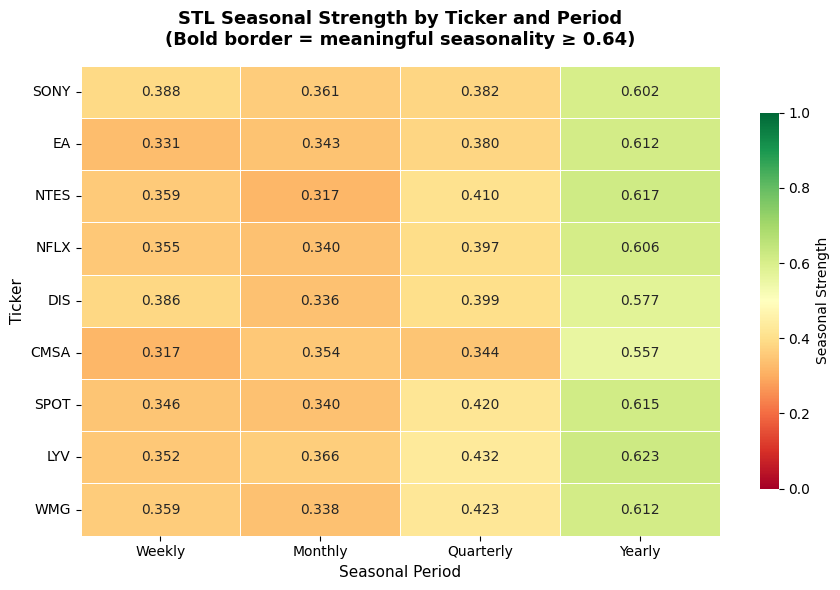

In [47]:
from statsmodels.tsa.seasonal import STL

PERIODS = [5, 21, 63, 252]
PERIOD_LABELS = {
    5: "Weekly",
    21: "Monthly",
    63: "Quarterly",
    252: "Yearly",
}


def stl_decomposition(ticker_data, ticker, series_name):
    df = ticker_data[ticker].copy()
    df.set_index("Date", inplace=True)
    series = df[series_name].dropna()

    for period in PERIODS:
        stl = STL(series, period=period)
        result = stl.fit()

        seasonal_strengh = 1 - (
            result.resid.var() / (result.seasonal + result.resid).var()
        )
        ticker_data[ticker][f"{series_name}_Seasonal_{period}"] = seasonal_strengh


def plot_seasonal_strengths(ticker_data, series_name):
    records = {}
    for ticker in TICKERS:
        records[ticker] = {
            PERIOD_LABELS[p]: ticker_data[ticker][f"{series_name}_Seasonal_{p}"].iloc[0]
            for p in PERIODS
        }

    heatmap_data = pd.DataFrame(records).T.astype(float)

    fig, ax = plt.subplots(figsize=(9, 6))

    sns.heatmap(
        heatmap_data,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="RdYlGn",  # Red = weak, Yellow = moderate, Green = strong
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Seasonal Strength", "shrink": 0.8},
    )

    for i, period in enumerate(PERIODS):
        for j, ticker in enumerate(TICKERS):
            val = heatmap_data.loc[ticker, PERIOD_LABELS[period]]
            if val >= 0.64:
                ax.add_patch(
                    plt.Rectangle((i, j), 1, 1, fill=False, edgecolor="black", lw=2.5)
                )

    ax.set_title(
        "STL Seasonal Strength by Ticker and Period\n(Bold border = meaningful seasonality ≥ 0.64)",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xlabel("Seasonal Period", fontsize=11)
    ax.set_ylabel("Ticker", fontsize=11)
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.savefig("seasonal_strength_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()


for ticker in TICKERS:
    stl_decomposition(ticker_data, ticker, "Intraday_Action_Pct")

plot_seasonal_strengths(ticker_data, "Intraday_Action_Pct")

## SARIMAX


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# From Granger causality results
SARIMAX_CONFIG = {
    "DIS": "SONY",
    "SPOT": "DIS",
    "WMG": "EA",
    "EA": "SONY",
}
SARIMA_TICKERS = ["SONY", "NTES", "CMSA", "NFLX", "LYV"]

# Seasonal order based on STL: mild yearly seasonality
# d=0, D=0 since ADF confirmed stationarity
ORDER = (1, 0, 1)
SEASONAL_ORDER = (1, 0, 1, 252)

results = {}

# SARIMA
for ticker in SARIMA_TICKERS:
    series = ticker_data[ticker]["Intraday_Action_Pct"].reset_index(drop=True).dropna()

    model = SARIMAX(
        series,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    results[ticker] = {
        "model": "SARIMA",
        "fit": fit,
        "exog_ticker": None,
        "aic": fit.aic,
        "bic": fit.bic,
    }
    print(f"SARIMA  {ticker:<6} | AIC: {fit.aic:.2f} | BIC: {fit.bic:.2f}")

# SARIMAX
for ticker, exog_ticker in SARIMAX_CONFIG.items():
    series = ticker_data[ticker]["Intraday_Action_Pct"].reset_index(drop=True).dropna()

    # Use lagged exog to avoid lookahead bias
    exog = (
        ticker_data[exog_ticker]["Intraday_Action_Pct"]
        .shift(1)
        .reset_index(drop=True)
        .dropna()
    )

    # Align lengths after shift drops one row
    min_len = min(len(series), len(exog))
    series = series.iloc[:min_len]
    exog = exog.iloc[:min_len]

    model = SARIMAX(
        series,
        exog=exog,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    results[ticker] = {
        "model": "SARIMAX",
        "fit": fit,
        "exog_ticker": exog_ticker,
        "aic": fit.aic,
        "bic": fit.bic,
    }
    print(
        f"SARIMAX {ticker:<6} | AIC: {fit.aic:.2f} | BIC: {fit.bic:.2f} | Exog: {exog_ticker}"
    )

In [ ]:
# Sanity check: does SARIMAX actually beat SARIMA for these tickers?
for ticker, exog_ticker in SARIMAX_CONFIG.items():
    sarimax_aic = results[ticker]["aic"]

    series = ticker_data[ticker]["Intraday_Action_Pct"].reset_index(drop=True).dropna()
    baseline = SARIMAX(
        series,
        order=ORDER,
        seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)

    delta = baseline.aic - sarimax_aic
    print(
        f"{ticker}: SARIMA AIC {baseline.aic:.2f} vs SARIMAX AIC {sarimax_aic:.2f} | ΔAIC: {delta:.2f}"
    )
    print(f"  → {'SARIMAX justified' if delta > 2 else 'Marginal or no improvement'}")